<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana3/Semana3_Treinamento_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Sucesso! O TensorFlow encontrou {len(gpus)} GPU(s) pronta(s) para uso.")
else:
    print("Nenhuma GPU encontrada. O código rodará na CPU.")

print("="*60)
print("PROJETO SEMANA 3: TREINAMENTO E VALIDAÇÃO (DATASET SONAR)")
print("="*60)

Sucesso! O TensorFlow encontrou 1 GPU(s) pronta(s) para uso.
PROJETO SEMANA 3: TREINAMENTO E VALIDAÇÃO (DATASET SONAR)


## Aula 1

In [3]:
# ==============================================================================
# AULA 1: PREPARANDO OS DADOS REAIS
# ==============================================================================
print("\n[AULA 1] IMPORTANDO E PREPARANDO O DATASET SONAR...")

url_dataset = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
df = pd.read_csv(url_dataset, header=None)

# O dataset tem 60 colunas de sensores (Features) e 1 coluna alvo (Rock ou Mine)
X_dados = df.iloc[:, 0:60].values
Y_texto = df.iloc[:, 60].values

# Convertendo R (Rock) e M (Mine) para números (1 e 0)
encoder = LabelEncoder()
Y_dados = encoder.fit_transform(Y_texto) # M vira 0, R vira 1

print(f"-> Base carregada com {len(X_dados)} leituras de sonar.")
print(f"-> Formato de X (Entrada): {X_dados.shape} -> (Amostras, Sensores)")
print(f"-> Formato de Y (Saída): {Y_dados.shape}")


[AULA 1] IMPORTANDO E PREPARANDO O DATASET SONAR...
-> Base carregada com 208 leituras de sonar.
-> Formato de X (Entrada): (208, 60) -> (Amostras, Sensores)
-> Formato de Y (Saída): (208,)


In [4]:
print(Y_texto)

['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R'
 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R'
 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R'
 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R'
 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R'
 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M'
 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M'
 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M'
 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M'
 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M'
 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M'
 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M']


In [5]:
print(Y_dados)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [6]:
df.head(10)

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
5,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,...,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,R
6,0.0317,0.0956,0.1321,0.1408,0.1674,0.1710,0.0731,0.1401,0.2083,0.3513,...,0.0201,0.0248,0.0131,0.0070,0.0138,0.0092,0.0143,0.0036,0.0103,R
7,0.0519,0.0548,0.0842,0.0319,0.1158,0.0922,0.1027,0.0613,0.1465,0.2838,...,0.0081,0.0120,0.0045,0.0121,0.0097,0.0085,0.0047,0.0048,0.0053,R
8,0.0223,0.0375,0.0484,0.0475,0.0647,0.0591,0.0753,0.0098,0.0684,0.1487,...,0.0145,0.0128,0.0145,0.0058,0.0049,0.0065,0.0093,0.0059,0.0022,R
9,0.0164,0.0173,0.0347,0.0070,0.0187,0.0671,0.1056,0.0697,0.0962,0.0251,...,0.0090,0.0223,0.0179,0.0084,0.0068,0.0032,0.0035,0.0056,0.0040,R


In [7]:
# ==============================================================================
# AULA 1: CONSTRUINDO A ARQUITETURA E COMPILANDO
# ==============================================================================
print("\n[AULA 1] CONSTRUINDO O MODELO NO KERAS...")

modelo_sonar = Sequential(name="Radar_IA_V1")
modelo_sonar.add(Input(shape=(60,), name="Entrada_60_Sensores"))
modelo_sonar.add(Dense(32, activation='relu', name="Oculta_1"))
modelo_sonar.add(Dense(16, activation='relu', name="Oculta_2"))
# Camada de saída com Sigmoid para Probabilidade Binária (0 a 1)
modelo_sonar.add(Dense(1, activation='sigmoid', name="Saida_Binaria"))

print("\n" + "="*60)
print("-> O RAIO-X DA NOSSA ARQUITETURA:")
modelo_sonar.summary()
print("="*60)


[AULA 1] CONSTRUINDO O MODELO NO KERAS...

-> O RAIO-X DA NOSSA ARQUITETURA:


Model: "Radar_IA_V1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Oculta_1 (Dense)                │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Oculta_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saida_Binaria (Dense)           │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
modelo_sonar.summary(show_trainable=True)

Model: "Radar_IA_V1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ Oculta_1 (Dense)            │ (None, 32)            │      1,952 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ Oculta_2 (Dense)            │ (None, 16)            │        528 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ Saida_Binaria (Dense)       │ (None, 1)             │         17 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

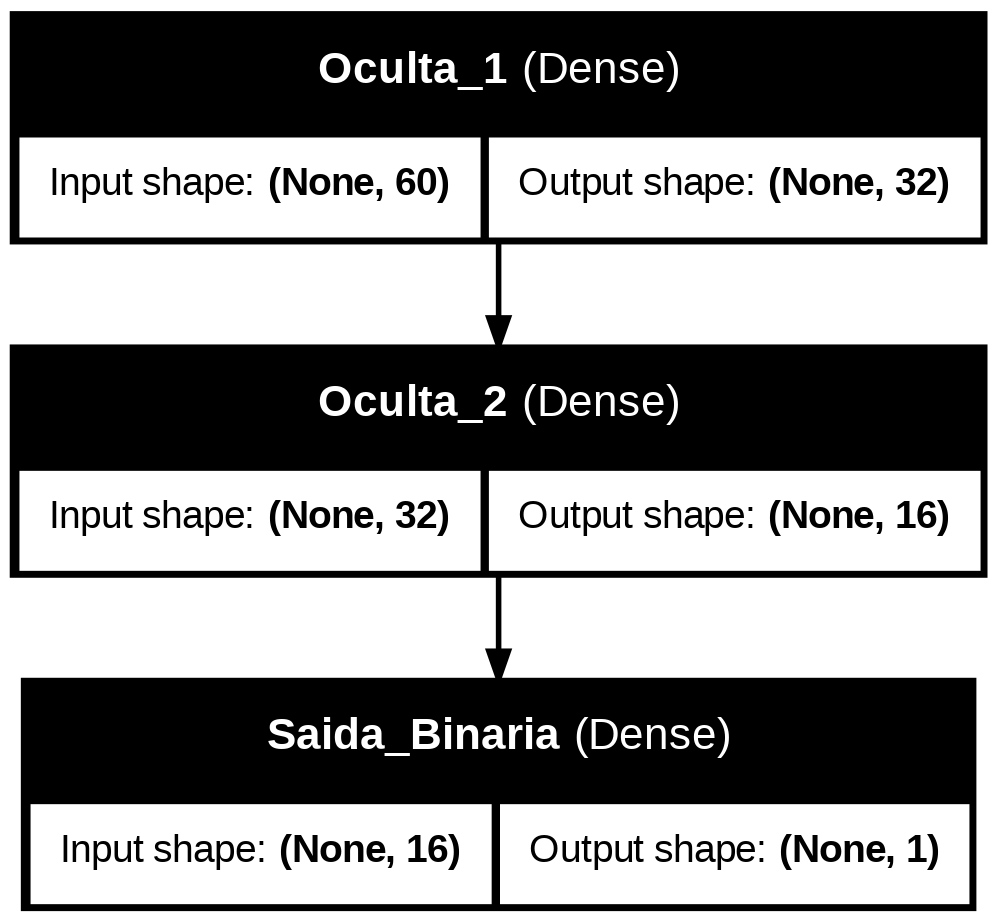

In [9]:
import keras

# Gera um arquivo de imagem mostrando as caixas de Input e Output
keras.utils.plot_model(
    modelo_sonar,
    to_file='modelo.png',
    show_shapes=True,
    show_layer_names=True
)


In [10]:
print("\n-> Teste prático com 3 leituras do sonar (ANTES DO TREINO):")
previsoes_iniciais = modelo_sonar(X_dados[:3])
for i in range(3):
    prob = previsoes_iniciais[i].numpy()[0]*100

    print(f"Leitura {i+1}: {prob:.2f}% de chance de ser uma Rocha.")

print("\n-> NOTEM: Os chutes estão beirando os 50% (incerteza total).")
print("A rede tem o cérebro, mas ainda não aprendeu. Faremos isso agora!")



-> Teste prático com 3 leituras do sonar (ANTES DO TREINO):
Leitura 1: 52.39% de chance de ser uma Rocha.
Leitura 2: 50.16% de chance de ser uma Rocha.
Leitura 3: 53.93% de chance de ser uma Rocha.

-> NOTEM: Os chutes estão beirando os 50% (incerteza total).
A rede tem o cérebro, mas ainda não aprendeu. Faremos isso agora!


## Aula 2

In [11]:
# COMPILANDO O MODELO (Escolhendo Juiz e Guia)
modelo_sonar.compile(
    optimizer='adam',                 # O Guia (Gradiente Descendente Inteligente)
    loss='binary_crossentropy',       # O Juiz (Avaliador para problemas Sim/Não)
    metrics=['accuracy']
)

In [12]:
# ==============================================================================
# AULA 2: DIVISÃO DE DADOS E O FREIO DE EMERGÊNCIA
# ==============================================================================
print("\n[AULA 2] SEPARANDO TREINO, VALIDAÇÃO E TESTE...")

# 1. Separando 20% para a Prova Final (Teste)
X_temp, X_test, Y_temp, Y_test = train_test_split(X_dados, Y_dados, test_size=0.15, random_state=42)

# 2. Separando 20% do resto para o Simulado (Validação)
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.15, random_state=42)


[AULA 2] SEPARANDO TREINO, VALIDAÇÃO E TESTE...


In [13]:
# Padronizando (Normalizando) as frequências do sonar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"-> Treino (Estudo): {len(X_train_scaled)} amostras")
print(f"-> Validação (Simulado): {len(X_val_scaled)} amostras")
print(f"-> Teste (Mar Aberto): {len(X_test_scaled)} amostras")

-> Treino (Estudo): 149 amostras
-> Validação (Simulado): 27 amostras
-> Teste (Mar Aberto): 32 amostras


In [14]:
# O GATILHO: Early Stopping
freio_emergencia = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # Fica olhando para o Erro da Validação
    patience=10,        # Tolerância de 10 épocas sem melhorar
    restore_best_weights=True # Pega os melhores pesos da história antes de travar
)

## Aula 2

In [17]:
# ==============================================================================
# AULA 2: TREINAMENTO E AVALIAÇÃO VISUAL
# ==============================================================================
print("\n[AULA 2] INICIANDO O TREINAMENTO (FIT)...")
print("Observe o val_loss. Se ele subir sem parar, o Keras vai puxar o freio!")

historico = modelo_sonar.fit(
    X_train_scaled, Y_train,
    validation_data=(X_val_scaled, Y_val),
    epochs=100,           # Número máximo de leituras completas do dataset
    batch_size=32, # Atualiza os pesos a cada 32 exemplos lidos
    shuffle=True, # embaralhad dados de treino para evitar vicios
    callbacks=[freio_emergencia],
    verbose=2
)


[AULA 2] INICIANDO O TREINAMENTO (FIT)...
Observe o val_loss. Se ele subir sem parar, o Keras vai puxar o freio!
Epoch 1/100
5/5 - 7s - 1s/step - accuracy: 0.3826 - loss: 0.7817 - val_accuracy: 0.5185 - val_loss: 0.6954
Epoch 2/100
5/5 - 0s - 22ms/step - accuracy: 0.4698 - loss: 0.7216 - val_accuracy: 0.5556 - val_loss: 0.6787
Epoch 3/100
5/5 - 0s - 20ms/step - accuracy: 0.5570 - loss: 0.6772 - val_accuracy: 0.5556 - val_loss: 0.6663
Epoch 4/100
5/5 - 0s - 21ms/step - accuracy: 0.6443 - loss: 0.6400 - val_accuracy: 0.6296 - val_loss: 0.6524
Epoch 5/100
5/5 - 0s - 21ms/step - accuracy: 0.6711 - loss: 0.6094 - val_accuracy: 0.5926 - val_loss: 0.6380
Epoch 6/100
5/5 - 0s - 20ms/step - accuracy: 0.7315 - loss: 0.5797 - val_accuracy: 0.6296 - val_loss: 0.6268
Epoch 7/100
5/5 - 0s - 23ms/step - accuracy: 0.7718 - loss: 0.5543 - val_accuracy: 0.7407 - val_loss: 0.6147
Epoch 8/100
5/5 - 0s - 21ms/step - accuracy: 0.7987 - loss: 0.5290 - val_accuracy: 0.7407 - val_loss: 0.6018
Epoch 9/100
5/5 

In [19]:
from sklearn.metrics import classification_report
print("\n" + "="*60)
print("TREINAMENTO CONCLUÍDO! Vamos colocar a rede para fazer PREVISÕES INÉDITAS.")
print("="*60)

# Fazendo a rede prever os dados que ela NUNCA viu (X_test_scaled)
previsoes_prob = modelo_sonar.predict(X_test_scaled)

# A rede retorna probabilidades (ex: 0.85). Vamos transformar em 0 (Mina) ou 1 (Rocha)
previsoes_finais = (previsoes_prob > 0.5).astype(int)

# Relatório Textual de Desempenho Industrial
print("\n-> RELATÓRIO DE CLASSIFICAÇÃO INDUSTRIAL (Precisão e Recall):")
print(classification_report(Y_test, previsoes_finais, target_names=['Mina Metálica (0)', 'Rocha (1)']))


TREINAMENTO CONCLUÍDO! Vamos colocar a rede para fazer PREVISÕES INÉDITAS.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

-> RELATÓRIO DE CLASSIFICAÇÃO INDUSTRIAL (Precisão e Recall):
                   precision    recall  f1-score   support

Mina Metálica (0)       0.94      0.89      0.92        19
        Rocha (1)       0.86      0.92      0.89        13

         accuracy                           0.91        32
        macro avg       0.90      0.91      0.90        32
     weighted avg       0.91      0.91      0.91        32



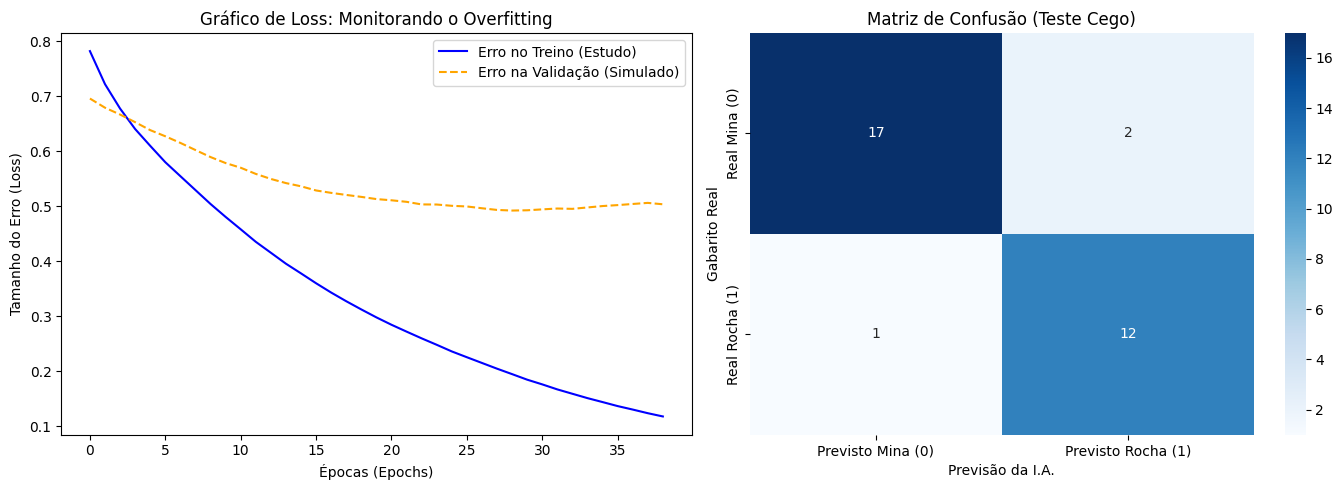


-> NOTEM NA MATRIZ DE CONFUSÃO: Onde cruzam 'Real Mina' e 'Previsto Rocha' é o nosso Falso Negativo.
Na indústria real, esse número precisa ser o mais próximo de zero possível!


In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
# Plotando os Gráficos (Evolução + Matriz de Confusão Lado a Lado)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Curvas de Aprendizado (Loss)
ax1.plot(historico.history['loss'], label='Erro no Treino (Estudo)', color='blue')
ax1.plot(historico.history['val_loss'], label='Erro na Validação (Simulado)', linestyle='--', color='orange')
ax1.set_title("Gráfico de Loss: Monitorando o Overfitting")
ax1.set_xlabel("Épocas (Epochs)")
ax1.set_ylabel("Tamanho do Erro (Loss)")
ax1.legend()

# Gráfico 2: Matriz de Confusão
matriz_confusao = confusion_matrix(Y_test, previsoes_finais)
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Previsto Mina (0)', 'Previsto Rocha (1)'],
            yticklabels=['Real Mina (0)', 'Real Rocha (1)'])
ax2.set_title("Matriz de Confusão (Teste Cego)")
ax2.set_xlabel("Previsão da I.A.")
ax2.set_ylabel("Gabarito Real")

plt.tight_layout()
plt.show()

print("\n-> NOTEM NA MATRIZ DE CONFUSÃO: Onde cruzam 'Real Mina' e 'Previsto Rocha' é o nosso Falso Negativo.")
print("Na indústria real, esse número precisa ser o mais próximo de zero possível!")